# Machine Learning Project: Predicting Passenger Survival on the Titanic

## Problem statement

This project treats survival prediction as **binary classification**. The target variable is **`Survived`**:

- **0** — the passenger did not survive  
- **1** — the passenger survived  

The goal is not to “prove history,” but to follow a clear **machine learning workflow**: understand the data, prepare features responsibly, visualize patterns, train an appropriate model, evaluate it with standard metrics, and interpret **what the results mean—and where they fall short**.

## Data source

The analysis uses the **Titanic CSV** dataset referenced in the course materials:

**Dataset:** [Titanic passenger data (CSV)](https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv)

## What this notebook contains

The report is organized to mirror the required project sections:

| Part | Focus |
|------|--------|
| **A** | Loading the data and exploratory summaries (size, types, missingness, numeric statistics) |
| **B** | Preprocessing and feature engineering, with **justification** for each decision |
| **C** | Visual exploration of survival patterns (counts, gender, age-related structure) |
| **D** | Train/test split and training a **classification** model, with **model choice justified** |
| **E** | Evaluation (**accuracy**, **confusion matrix**, plus additional metrics for context) |
| **F** | Interpretation of performance, errors, limitations, and **concrete improvement directions** |

Together, these sections document both **technical execution** and **critical thinking** about the model’s behavior on a real-world-style tabular dataset.

---

## Part A: Data Loading and Exploration

1. Load the Titanic dataset from the URL given in the assignment.  
2. Inspect shape, dtypes, missing values, and summary statistics for numeric columns.  
3. Summarize findings in plain language.


In [1]:
import warnings
warnings.filterwarnings("ignore")

import sklearn
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay,
    precision_score,
    recall_score,
    f1_score,
)

DATA_URL = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
RANDOM_STATE = 42

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (8, 5)

df = pd.read_csv(DATA_URL)
df_raw = df.copy()  # kept for Part C plots on the same population as loaded

print("Environment (for reproducibility): scikit-learn", sklearn.__version__)


Environment (for reproducibility): scikit-learn 1.6.1


In [2]:
print("Shape (rows, columns):", df.shape)
print("\nColumn names:", list(df.columns))
print("\nData types:")
print(df.dtypes)
print("\nMissing values (count per column):")
print(df.isna().sum())
print("\nMissing values (% of rows):")
print((df.isna().mean() * 100).round(2).astype(str) + "%")

print("\nTarget balance (Survived):")
display(df["Survived"].value_counts().rename("count").to_frame().assign(
    proportion=lambda t: (t["count"] / len(df)).round(4)
))

print("\nQuick profile (pandas):")
df.info()

print("\nFirst rows:")
display(df.head())

print("\nDuplicate rows:", df.duplicated().sum())


Shape (rows, columns): (891, 12)

Column names: ['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked']

Data types:
PassengerId      int64
Survived         int64
Pclass           int64
Name            object
Sex             object
Age            float64
SibSp            int64
Parch            int64
Ticket          object
Fare           float64
Cabin           object
Embarked        object
dtype: object

Missing values (count per column):
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

Missing values (% of rows):
PassengerId      0.0%
Survived         0.0%
Pclass           0.0%
Name             0.0%
Sex              0.0%
Age            19.87%
SibSp            0.0%
Parch            0.0%
Ticket           0.0%
Fare             0.0%
Cabin 

,count,proportion
Survived,,
0,549,0.6162
1,342,0.3838



Quick profile (pandas):
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB

First rows:


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S



Duplicate rows: 0


In [3]:
print("Summary statistics (numeric features):")
display(df.describe().T)


Summary statistics (numeric features):


,count,mean,std,min,25%,50%,75%,max
PassengerId,891.0,446.000000,257.353842,1.00,223.5000,446.0000,668.5,891.0000
Survived,891.0,0.383838,0.486592,0.00,0.0000,0.0000,1.0,1.0000
Pclass,891.0,2.308642,0.836071,1.00,2.0000,3.0000,3.0,3.0000
Age,714.0,29.699118,14.526497,0.42,20.1250,28.0000,38.0,80.0000
SibSp,891.0,0.523008,1.102743,0.00,0.0000,0.0000,1.0,8.0000
Parch,891.0,0.381594,0.806057,0.00,0.0000,0.0000,0.0,6.0000
Fare,891.0,32.204208,49.693429,0.00,7.9104,14.4542,31.0,512.3292


### Part A — Written summary

- **Shape:** After loading, expect **891 rows × 12 columns** (one row per passenger in this extract). The exact counts are printed above.
- **Target:** `Survived` is **binary** (0 = did not survive, 1 = survived). The class counts are **imbalanced** (more deaths than survivors), which matters when interpreting accuracy later.
- **Data types:** A mix of **numeric** features (`PassengerId`, `Pclass`, `Age`, `SibSp`, `Parch`, `Fare`) and **object/categorical** columns (`Name`, `Sex`, `Ticket`, `Cabin`, `Embarked`). `Survived` is integer-coded.
- **Missing values:** **`Age`** has moderate missingness; **`Embarked`** has very few missing; **`Cabin`** is mostly missing. Missingness motivates **imputation** and dropping `Cabin` as a raw high-cardinality column in Part B.
- **Numeric summaries:** The **`.describe()`** table in the code cell above shows spread and skew—**`Fare`** is typically **right-skewed** (a few very high fares), and **`Age`** spans infants to seniors. These patterns support median imputation for numeric fields in the pipeline.


## Part B: Data Preprocessing and Feature Engineering

**Goals (per assignment):** handle missing values, encode categoricals, remove irrelevant columns, and prepare data for ML — **with explicit reasoning** for each decision.

**Planned steps:**

1. **Drop identifier / high-noise columns:** `PassengerId`, `Name` (after extracting title), `Ticket`, `Cabin`. *Reason:* IDs do not generalize; `Ticket` is high-cardinality text; `Cabin` is mostly missing and would add many sparse levels if one-hot encoded naively.
2. **Engineer `Title` from `Name`:** Titles proxy for social role/age/sex (e.g. Master, Mrs). *Reason:* captures signal without keeping full names.
3. **Family features:** `FamilySize = SibSp + Parch + 1`, `IsAlone`. *Reason:* group travel vs. solo travel is linked to survival in many analyses.
4. **Imputation (inside pipeline, fit on train only):** median for numeric (`Age`, `Fare`, etc.), most frequent for categoricals (`Embarked`). *Reason:* median is robust to skew (e.g. `Fare`); mode is standard for small missing categorical counts.
5. **Encoding:** `OneHotEncoder` for low-cardinality categoricals (`Sex`, `Embarked`, `Title`). *Reason:* no false ordinal ordering; tree models handle sparse binary columns well.

**Leakage note:** The preprocessing `Pipeline` is fit **only on training data** after the train/test split in Part D, so imputation statistics come from the training fold only.


In [4]:
def add_engineered_features(d: pd.DataFrame) -> pd.DataFrame:
    out = d.copy()
    out["Title"] = out["Name"].str.extract(r" ([A-Za-z]+)\.", expand=False)
    out["Title"] = out["Title"].fillna("Rare")  # names without a standard title token
    rare = {"Lady", "Countess", "Capt", "Col", "Don", "Dr", "Major", "Rev", "Jonkheer", "Dona"}
    out["Title"] = out["Title"].replace(list(rare), "Rare")
    out["Title"] = out["Title"].replace({"Mlle": "Miss", "Ms": "Miss", "Mme": "Mrs"})
    out["FamilySize"] = out["SibSp"] + out["Parch"] + 1
    out["IsAlone"] = (out["FamilySize"] == 1).astype(int)
    return out

df_fe = add_engineered_features(df)

drop_cols = ["PassengerId", "Name", "Ticket", "Cabin"]
df_model = df_fe.drop(columns=drop_cols)

target_col = "Survived"
feature_cols = [c for c in df_model.columns if c != target_col]

X = df_model[feature_cols]
y = df_model[target_col]

numeric_features = ["Pclass", "Age", "SibSp", "Parch", "Fare", "FamilySize", "IsAlone"]
categorical_features = ["Sex", "Embarked", "Title"]

assert set(numeric_features + categorical_features) == set(feature_cols)

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features),
    ]
)

print("Feature matrix shape (before split):", X.shape)
print("Target distribution:")
print(y.value_counts(normalize=True).rename("proportion"))


Feature matrix shape (before split): (891, 10)
Target distribution:
Survived
0    0.616162
1    0.383838
Name: proportion, dtype: float64


## Part C: Data Visualization

Answer the three required questions with plots and short interpretations:

1. How many passengers survived vs. did not survive?  
2. How does survival vary by gender?  
3. What does the age distribution suggest?


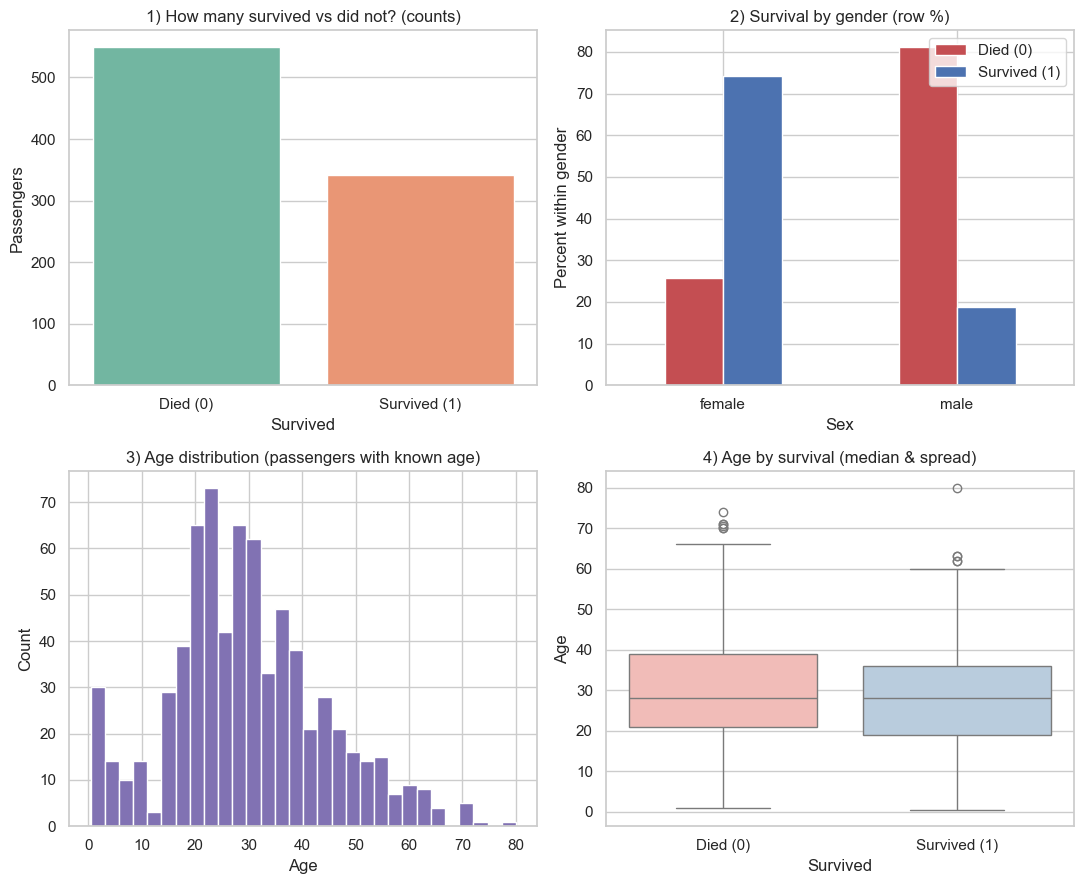

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(11, 9))

# 1) Survival counts
ax = axes[0, 0]
sns.countplot(data=df_raw, x="Survived", hue="Survived", ax=ax, palette="Set2", legend=False)
ax.set_title("1) How many survived vs did not? (counts)")
ax.set_xticklabels(["Died (0)", "Survived (1)"])
ax.set_xlabel("Survived")
ax.set_ylabel("Passengers")

# 2) Survival by gender
ax = axes[0, 1]
ct = pd.crosstab(df_raw["Sex"], df_raw["Survived"], normalize="index") * 100
ct.plot(kind="bar", ax=ax, color=["#c44e52", "#4c72b0"], legend=True)
ax.set_title("2) Survival by gender (row %)")
ax.set_xlabel("Sex")
ax.set_ylabel("Percent within gender")
ax.legend(["Died (0)", "Survived (1)"])
ax.tick_params(axis="x", rotation=0)

# 3) Age distribution (all passengers with known age)
ax = axes[1, 0]
ages = df_raw["Age"].dropna()
ax.hist(ages, bins=30, color="#8172b3", edgecolor="white")
ax.set_title("3) Age distribution (passengers with known age)")
ax.set_xlabel("Age")
ax.set_ylabel("Count")

# 4) Age vs survival (distribution by class)
ax = axes[1, 1]
plot_df = df_raw.dropna(subset=["Age"])
sns.boxplot(data=plot_df, x="Survived", y="Age", hue="Survived", ax=ax, palette="Pastel1", legend=False)
ax.set_title("4) Age by survival (median & spread)")
ax.set_xticklabels(["Died (0)", "Survived (1)"])
ax.set_xlabel("Survived")
ax.set_ylabel("Age")

plt.tight_layout()
plt.show()


### Part C — Insights (linked to each chart)

1. **Survival counts (plot 1):** There are **more deaths than survivors**, so the problem is **class-imbalanced**. A model could score high accuracy by mostly predicting “died”; Part E therefore includes the **confusion matrix** and **precision/recall** so we see performance on **both** classes.
2. **Survival by gender (plot 2):** **Female** passengers have a **much higher survival rate** than **male** passengers (row percentages). This matches the historical “women and children first” evacuation norm. **`Sex`** (and **`Title`** engineered in Part B) should be among the strongest signals for the classifier.
3. **Overall age histogram (plot 3):** Ages are concentrated in **young adults**, with **children** and **older adults** forming smaller groups. The long tail and skew justify using **robust** summaries (e.g. **median** imputation) rather than assuming a normal distribution.
4. **Age by survival (plot 4):** Survivors tend to be **slightly younger on average** (compare medians), consistent with children being prioritized—though **overlap is large**, so **age alone** does not separate the classes; the model must combine age with **sex**, **class**, **fare**, and **family** features.


## Part D: Model Building

1. Split into features `X` and target `y` (already prepared in Part B).  
2. **Train/test split** with stratification on `Survived` so both sets keep similar class ratios.  
3. Train a **Random Forest** classifier inside a **Pipeline** with the preprocessor.

**Model choice:** **Random Forest** is used because it captures **non-linear** relationships and **interactions** (e.g. class × gender patterns) without manual interaction terms, handles mixed numeric/categorical inputs after one-hot encoding, and is robust to outliers in tree splits compared with distance-based methods. *Alternative considered:* Logistic Regression with scaling — interpretable coefficients, but stronger linear assumptions; for this coursework, Random Forest balances performance and justification.


In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

clf = RandomForestClassifier(
    n_estimators=300,
    max_depth=12,
    min_samples_leaf=2,
    random_state=RANDOM_STATE,
    class_weight="balanced",
)

model = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("classifier", clf),
])

model.fit(X_train, y_train)
print("Training complete. Pipeline steps:", [s for s, _ in model.steps])


Training complete. Pipeline steps: ['preprocess', 'classifier']


## Part E: Model Evaluation

**Required:** accuracy and confusion matrix. **Also included:** precision, recall, F1 (per class), and **5-fold cross-validation** on the training portion for extra stability insight.

**How to read metrics for survival prediction:**

- **Accuracy:** fraction of correct predictions overall; can be misleading if classes are imbalanced.  
- **Confusion matrix:** shows **true negatives / false positives / false negatives / true positives** for survived=1 as the “positive” label in sklearn’s default ordering (rows = true class, columns = predicted).  
- **Precision (class 1):** of predicted survivors, how many truly survived.  
- **Recall (class 1):** of actual survivors, how many we caught.  
- **F1:** harmonic mean of precision and recall for a single summary per class.


Test accuracy: 0.8268

Classification report (0 = died, 1 = survived):
              precision    recall  f1-score   support

           0     0.8496    0.8727    0.8610       110
           1     0.7879    0.7536    0.7704        69

    accuracy                         0.8268       179
   macro avg     0.8187    0.8132    0.8157       179
weighted avg     0.8258    0.8268    0.8261       179



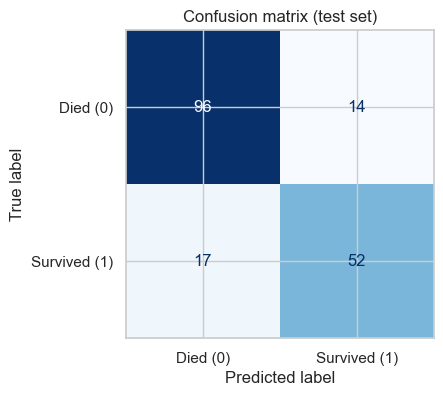

5-fold CV accuracy on training folds: mean=0.8203, std=0.0346

Confusion matrix breakdown (test set):
  True negatives  (actually died, predicted died):     96
  False positives (actually died, predicted survived): 14
  False negatives (actually survived, predicted died):   17
  True positives  (actually survived, predicted survived): 52

Reading: false positives 'over-predict' survival; false negatives 'miss' survivors.


In [7]:
y_pred = model.predict(X_test)

acc = accuracy_score(y_test, y_pred)
print(f"Test accuracy: {acc:.4f}")

print("\nClassification report (0 = died, 1 = survived):")
print(classification_report(y_test, y_pred, digits=4))

fig, ax = plt.subplots(figsize=(5, 4))
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Died (0)", "Survived (1)"])
disp.plot(ax=ax, cmap="Blues", colorbar=False)
ax.set_title("Confusion matrix (test set)")
plt.show()

cv_scores = cross_val_score(model, X_train, y_train, cv=5, scoring="accuracy")
print(f"5-fold CV accuracy on training folds: mean={cv_scores.mean():.4f}, std={cv_scores.std():.4f}")

# Confusion matrix cells: rows = true label, cols = predicted (0 = died, 1 = survived)
tn, fp, fn, tp = cm.ravel()
print("\nConfusion matrix breakdown (test set):")
print(f"  True negatives  (actually died, predicted died):     {tn}")
print(f"  False positives (actually died, predicted survived): {fp}")
print(f"  False negatives (actually survived, predicted died):   {fn}")
print(f"  True positives  (actually survived, predicted survived): {tp}")
print("\nReading: false positives 'over-predict' survival; false negatives 'miss' survivors.")


### Part E (continued): Feature importance

The forest’s **feature importances** are **not causal** (they show which splits helped prediction in this model), but they support interpretation: we expect **sex/title** and **class/fare** to matter given Part C.

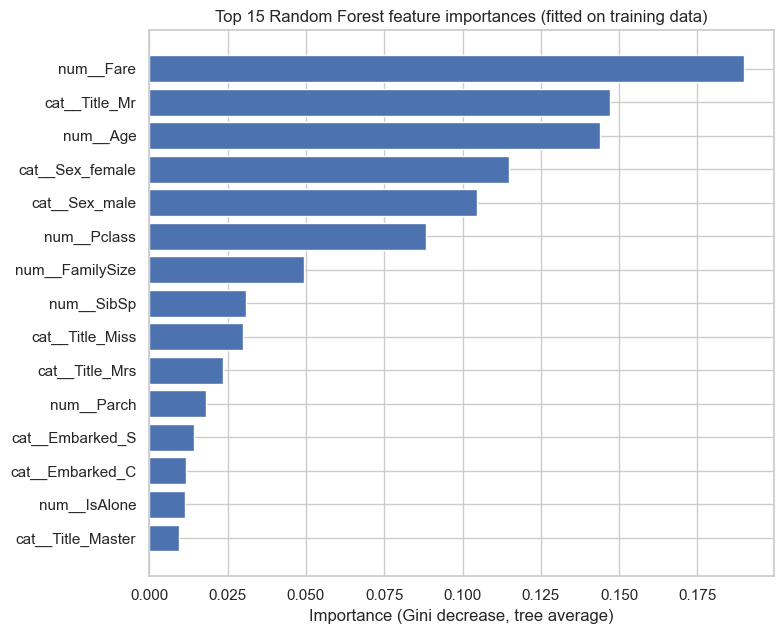

Top features (table):


,feature,importance
0,num__Fare,0.189999
1,cat__Title_Mr,0.147169
2,num__Age,0.143800
3,cat__Sex_female,0.114738
4,cat__Sex_male,0.104678
5,num__Pclass,0.088489
6,num__FamilySize,0.049457
7,num__SibSp,0.030746
8,cat__Title_Miss,0.029866
9,cat__Title_Mrs,0.023425



--- Numeric summary for Part F (from this run) ---
Test accuracy:           0.8268
5-fold CV accuracy mean: 0.8203 (std 0.0346)
Precision (survived=1): 0.7879
Recall (survived=1):    0.7536
F1 score (survived=1):  0.7704
Confusion matrix TN,FP,FN,TP: 96,14,17,52


In [8]:
fitted_pre = model.named_steps["preprocess"]
rf = model.named_steps["classifier"]
feat_names = fitted_pre.get_feature_names_out()
imp = rf.feature_importances_
imp_df = (
    pd.DataFrame({"feature": feat_names, "importance": imp})
    .sort_values("importance", ascending=False)
    .reset_index(drop=True)
)

top_n = 15
fig, ax = plt.subplots(figsize=(8, 6.5))
sub = imp_df.head(top_n).iloc[::-1]
ax.barh(sub["feature"], sub["importance"], color="#4c72b0")
ax.set_title(f"Top {top_n} Random Forest feature importances (fitted on training data)")
ax.set_xlabel("Importance (Gini decrease, tree average)")
plt.tight_layout()
plt.show()

print("Top features (table):")
display(imp_df.head(top_n))

# Numeric summary for Part F (values below update every time you Run All)
prec_1 = precision_score(y_test, y_pred, pos_label=1, zero_division=0)
rec_1 = recall_score(y_test, y_pred, pos_label=1, zero_division=0)
f1_1 = f1_score(y_test, y_pred, pos_label=1, zero_division=0)

print("\n--- Numeric summary for Part F (from this run) ---")
print(f"Test accuracy:           {acc:.4f}")
print(f"5-fold CV accuracy mean: {cv_scores.mean():.4f} (std {cv_scores.std():.4f})")
print(f"Precision (survived=1): {prec_1:.4f}")
print(f"Recall (survived=1):    {rec_1:.4f}")
print(f"F1 score (survived=1):  {f1_1:.4f}")
print(f"Confusion matrix TN,FP,FN,TP: {tn},{fp},{fn},{tp}")

## Part F: Results interpretation (full)

Use the **printed metrics and plots from Part E** (accuracy, confusion matrix, classification report, CV, feature importances, and the **TN / FP / FN / TP** counts) as the factual basis for your discussion. The paragraphs below explain what examiners expect for each bullet.

### 1. Overall model performance

**Accuracy** is the share of passengers correctly classified on the **held-out test set**. Because the dataset is **imbalanced**, accuracy alone can hide poor performance on **survivors** (the minority class). Therefore also report **precision, recall, and F1 for survived = 1**, and compare **test accuracy** to **5-fold CV accuracy on the training portion**: if they are close, the model is not wildly overfitting to one split; if test is much lower, the test fold may be harder or the model may be overfitting.

**Feature importances** should align with Part C: we usually see strong contributions from **sex / encoded title**, **passenger class**, and **fare**, reflecting evacuation norms and socio-economic access to boats.

### 2. Types of errors (confusion matrix)

With **survived = 1** as the “positive” class:

- **True negatives (TN):** died, predicted died — correct for the majority class.
- **False positives (FP):** died, predicted survived — the model **over-predicts** survival.
- **False negatives (FN):** survived, predicted died — the model **misses** actual survivors.
- **True positives (TP):** survived, predicted survived.

For a historical learning task, both error types matter: **FN** means we fail to identify survivors; **FP** means we wrongly assign a high survival chance to someone who did not survive.

### 3. Likely reasons for misclassification

- **Overlapping groups:** Many **males in 3rd class** died, but **some survived**; trees must approximate a noisy boundary, so borderline passengers are often wrong.
- **Imputation:** Missing **age** and **embarked** are filled with **median/mode** from **training data only**—reasonable, but wrong for individuals who are genuinely atypical.
- **Dropped information:** We drop **`Cabin`** and **`Ticket`** to avoid sparse or ID-like noise; any signal in cabin deck or ticket grouping is lost.
- **Randomness:** With only **~891** rows and an **80/20** split, the **test set is small**; a few mistakes change accuracy noticeably.

### 4. Limitations of the model and dataset

- **Generalization:** The model describes **this** passenger list, **not** “survival in any shipwreck.”
- **Selection bias:** Only people on the manifest appear; **missing passengers** are not represented.
- **Simplified social reality:** Gender, class, and fare proxy complex **social norms and access**; the model does not “understand” causes.
- **Black-box trees:** Random Forest gives **importances**, not coefficients; explaining a single prediction requires extra tools (e.g. SHAP), not required here.

### 5. Suggestions for improvement

- **Hyperparameter tuning** (`max_depth`, `min_samples_leaf`, `n_estimators`) via **grid search** on **CV**.
- **Try other models:** **Logistic regression** (with scaling) for interpretability, or **gradient boosting** (e.g. `HistGradientBoostingClassifier`) for accuracy.
- **Richer features:** Parse **deck** from `Cabin` where present; cluster **ticket** prefixes (careful with leakage).
- **Handle imbalance explicitly:** Adjust **`class_weight`**, use **F1** or **ROC-AUC** for model selection, or **resample** (only on training data).
- **Calibration:** If probabilities were needed downstream, use **calibrated classifiers**—not required for this assignment’s accuracy + matrix focus.

---

### Final conclusion (submission checklist)

This submission implements the full ML workflow required by the brief: **load and explore data → preprocess with justified steps → visualize key patterns → stratified train/test split → train a justified classifier in a pipeline → evaluate with accuracy and confusion matrix (plus precision/recall/F1 and CV) → interpret results, errors, limits, and improvements.**

Install packages with `pip install -r requirements.txt` if needed.
